#Setup and Environment (Colab + GPU)

In [ ]:
!rm -rf /content/drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Feature Selection

In [ ]:
import pandas as pd
import numpy as np

# Path to your file
file_path = '/content/drive/MyDrive/Telementors/Fare/train_scaled_rolling.csv'

# First, let's read the file without specifying usecols to inspect the available columns
temp_df = pd.read_csv(file_path)
print("Available columns in the CSV file:")
print(temp_df.columns.tolist())

df = temp_df
df.head()

/tmp/ipykernel_4915/745316043.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file_path)


Available columns in the CSV file:
['2', '2025-08-01 00:52:23', '2025-08-01 01:12:20', '1.0', '8.44', '1.0.1', 'N', '138', '141', '1', '33.8', '6.0', '0.5', '5.0', '6.94', '1.0.2', '57.49', '2.5', '1.75', '0.0']


,2,2025-08-01 00:52:23,2025-08-01 01:12:20,1.0,8.44,1.0.1,N,138,141,1,33.8,6.0,0.5,5.0,6.94,1.0.2,57.49,2.5,1.75,0.0
0,0.166667,2025-08-01 00:03:01,2025-08-01 00:15:33,0.222222,1.044521,0.0,N,-0.339220,0.462773,0.25,0.476190,2.674491,0.090909,-0.5000,0.0,1.0,0.580207,0.5,0.411765,-1.482463
1,1.000000,2025-08-01 00:24:38,2025-08-01 00:24:38,0.222222,-0.013699,0.0,N,1.333592,-1.629115,0.25,0.000000,-0.628040,0.090909,0.4975,0.0,1.0,0.159120,1.0,0.205882,0.603054
2,1.000000,2025-08-01 00:48:19,2025-08-01 00:48:19,0.111111,0.143836,0.0,N,-1.228372,0.971611,0.25,-0.190476,-0.628040,0.090909,0.3575,0.0,1.0,-0.058215,1.0,0.205882,0.603054
3,0.166667,2025-08-01 00:25:34,2025-08-01 00:33:18,0.111111,0.071918,0.0,N,-1.770906,-1.586712,0.25,-0.190476,-0.077618,0.090909,0.1425,0.0,1.0,-0.113842,1.0,0.205882,0.603054
4,0.166667,2025-08-01 00:16:36,2025-08-01 00:33:41,0.111111,0.386986,0.0,N,-0.700909,0.985745,0.50,0.285714,-0.077618,0.090909,-0.5000,0.0,1.0,0.172704,1.0,0.205882,0.603054


#Replacing numbers with column names

In [ ]:
import pandas as pd

# List of column names in order
columns = [
    'provider_code', 'pickup_timestamp', 'dropoff_timestamp', 'rider_count',
    'distance_miles', 'rate_class_id', 'offline_record_flag', 'origin_loc_id',
    'dest_loc_id', 'fare_settlement_method', 'base_fare', 'surcharge_misc',
    'transit_tax', 'driver_tip_payment', 'toll_total', 'service_improvement_fee',
    'charge_total', 'zone_congestion_fee', 'Airport_fee', 'congestion_relief_fee'
]

file_path = '/content/drive/MyDrive/Telementors/Fare/train_scaled_rolling.csv'

# Read CSV and assign column names (header=None prevents the 1st row from becoming headers)
df = pd.read_csv(file_path, header=None, names=columns, low_memory=False)
df.head()

,provider_code,pickup_timestamp,dropoff_timestamp,rider_count,distance_miles,rate_class_id,offline_record_flag,origin_loc_id,dest_loc_id,fare_settlement_method,base_fare,surcharge_misc,transit_tax,driver_tip_payment,toll_total,service_improvement_fee,charge_total,zone_congestion_fee,Airport_fee,congestion_relief_fee
0,2.000000,2025-08-01 00:52:23,2025-08-01 01:12:20,1.000000,8.440000,1.0.1,N,138.000000,141.000000,1.00,33.800000,6.000000,0.500000,5.0000,6.94,1.0.2,57.490000,2.5,1.750000,0.000000
1,0.166667,2025-08-01 00:03:01,2025-08-01 00:15:33,0.222222,1.044521,0.0,N,-0.339220,0.462773,0.25,0.476190,2.674491,0.090909,-0.5000,0.00,1.0,0.580207,0.5,0.411765,-1.482463
2,1.000000,2025-08-01 00:24:38,2025-08-01 00:24:38,0.222222,-0.013699,0.0,N,1.333592,-1.629115,0.25,0.000000,-0.628040,0.090909,0.4975,0.00,1.0,0.159120,1.0,0.205882,0.603054
3,1.000000,2025-08-01 00:48:19,2025-08-01 00:48:19,0.111111,0.143836,0.0,N,-1.228372,0.971611,0.25,-0.190476,-0.628040,0.090909,0.3575,0.00,1.0,-0.058215,1.0,0.205882,0.603054
4,0.166667,2025-08-01 00:25:34,2025-08-01 00:33:18,0.111111,0.071918,0.0,N,-1.770906,-1.586712,0.25,-0.190476,-0.077618,0.090909,0.1425,0.00,1.0,-0.113842,1.0,0.205882,0.603054


In [ ]:
import pandas as pd
import os

file_path = '/content/drive/MyDrive/Telementors/Fare/train_scaled_rolling.csv'
temp_path = '/content/drive/MyDrive/Telementors/Fare/train_scaled_rolling_temp.csv'

# List of column names in order
columns = [
    'provider_code', 'pickup_timestamp', 'dropoff_timestamp', 'rider_count',
    'distance_miles', 'rate_class_id', 'offline_record_flag', 'origin_loc_id',
    'dest_loc_id', 'fare_settlement_method', 'base_fare', 'surcharge_misc',
    'transit_tax', 'driver_tip_payment', 'toll_total', 'service_improvement_fee',
    'charge_total', 'zone_congestion_fee', 'Airport_fee', 'congestion_relief_fee'
]

CHUNK_SIZE = 100000

# Stream through the old file (skipping old header row) and write with new headers
first_chunk = True
for chunk in pd.read_csv(file_path, header=0, names=columns, chunksize=CHUNK_SIZE, low_memory=False):
    chunk.to_csv(temp_path, mode='w' if first_chunk else 'a', header=first_chunk, index=False)
    first_chunk = False

# Safely overwrite the old file with the newly headered file
os.replace(temp_path, file_path)

print(f"Successfully replaced headers and overwritten: {file_path}")

Successfully replaced headers and overwritten: /content/drive/MyDrive/Telementors/Fare/train_scaled_rolling.csv


In [ ]:
import pandas as pd
import gc

train_path = '/content/drive/MyDrive/Telementors/Fare/train_scaled_rolling.csv'
test_path = '/content/drive/MyDrive/Telementors/Fare/test_rolling.csv'
col_name = 'offline_record_flag'

CHUNK_SIZE = 200000  # Adjust if RAM is still constrained

# 1. Determine unique categories from the train set in chunks
unique_categories = set()
for chunk in pd.read_csv(train_path, usecols=[col_name], chunksize=CHUNK_SIZE):
    unique_categories.update(chunk[col_name].fillna('missing').astype(str).unique())

# Also scan test set for unseen values to create a complete mapping
for chunk in pd.read_csv(test_path, usecols=[col_name], chunksize=CHUNK_SIZE):
    unique_categories.update(chunk[col_name].fillna('missing').astype(str).unique())

# Build static mapping dictionary (e.g. {'N': 0, 'Y': 1})
encoding_map = {val: idx for idx, val in enumerate(sorted(unique_categories))}
print(f"Generated Mapping: {encoding_map}")

# 2. Helper function to process and save large CSV files in chunks
def encode_csv_in_chunks(input_file, output_file):
    first_chunk = True
    for chunk in pd.read_csv(input_file, chunksize=CHUNK_SIZE):
        # Apply integer mapping directly
        chunk[col_name] = chunk[col_name].fillna('missing').astype(str).map(encoding_map).astype('int8')

        # Save incrementally
        chunk.to_csv(output_file, mode='w' if first_chunk else 'a', header=first_chunk, index=False)
        first_chunk = False

        del chunk
        gc.collect()

# 3. Process train and test sets independently
print("Encoding train set...")
encode_csv_in_chunks(train_path, train_path)

print("Encoding test set...")
encode_csv_in_chunks(test_path, '/content/drive/MyDrive/Telementors/Fare/test_scaled_rolling.csv')

print("Encoding successfully completed without crashing RAM!")

/tmp/ipykernel_5718/1773541532.py:12: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(train_path, usecols=[col_name], chunksize=CHUNK_SIZE):
/tmp/ipykernel_5718/1773541532.py:12: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(train_path, usecols=[col_name], chunksize=CHUNK_SIZE):
/tmp/ipykernel_5718/1773541532.py:12: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(train_path, usecols=[col_name], chunksize=CHUNK_SIZE):
/tmp/ipykernel_5718/1773541532.py:12: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(train_path, usecols=[col_name], chunksize=CHUNK_SIZE):


Generated Mapping: {'0': 0, '1': 1, 'N': 2, 'Y': 3, 'missing': 4}
Encoding train set...
Encoding test set...


/tmp/ipykernel_5718/1773541532.py:26: DtypeWarning: Columns (0,3,4,5,7,8,9,10,11,12,13,14,15,16,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(input_file, chunksize=CHUNK_SIZE):


Encoding successfully completed without crashing RAM!


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Telementors/Fare/train_scaled_rolling.csv'

# Load only the first 5 rows to inspect the encoded dataset
df_preview = pd.read_csv(file_path, nrows=5)

# Display column data types and the first 5 rows
print("Data Types Preview:")
print(df_preview.dtypes)

print("\nFirst 5 Rows:")
df_preview.head()

Data Types Preview:
provider_code              float64
pickup_timestamp            object
dropoff_timestamp           object
rider_count                float64
distance_miles             float64
rate_class_id              float64
offline_record_flag          int64
origin_loc_id              float64
dest_loc_id                float64
fare_settlement_method     float64
base_fare                  float64
surcharge_misc             float64
transit_tax                float64
driver_tip_payment         float64
toll_total                 float64
service_improvement_fee    float64
charge_total               float64
zone_congestion_fee        float64
Airport_fee                float64
congestion_relief_fee      float64
dtype: object

First 5 Rows:


,provider_code,pickup_timestamp,dropoff_timestamp,rider_count,distance_miles,rate_class_id,offline_record_flag,origin_loc_id,dest_loc_id,fare_settlement_method,base_fare,surcharge_misc,transit_tax,driver_tip_payment,toll_total,service_improvement_fee,charge_total,zone_congestion_fee,Airport_fee,congestion_relief_fee
0,0.166667,2025-08-01 00:03:01,2025-08-01 00:15:33,0.222222,1.044521,0.0,2,-0.339220,0.462773,0.25,0.476190,2.674491,0.090909,-0.5000,0.0,1.0,0.580207,0.5,0.411765,-1.482463
1,1.000000,2025-08-01 00:24:38,2025-08-01 00:24:38,0.222222,-0.013699,0.0,2,1.333592,-1.629115,0.25,0.000000,-0.628040,0.090909,0.4975,0.0,1.0,0.159120,1.0,0.205882,0.603054
2,1.000000,2025-08-01 00:48:19,2025-08-01 00:48:19,0.111111,0.143836,0.0,2,-1.228372,0.971611,0.25,-0.190476,-0.628040,0.090909,0.3575,0.0,1.0,-0.058215,1.0,0.205882,0.603054
3,0.166667,2025-08-01 00:25:34,2025-08-01 00:33:18,0.111111,0.071918,0.0,2,-1.770906,-1.586712,0.25,-0.190476,-0.077618,0.090909,0.1425,0.0,1.0,-0.113842,1.0,0.205882,0.603054
4,0.166667,2025-08-01 00:16:36,2025-08-01 00:33:41,0.111111,0.386986,0.0,2,-0.700909,0.985745,0.50,0.285714,-0.077618,0.090909,-0.5000,0.0,1.0,0.172704,1.0,0.205882,0.603054


Feature building

In [ ]:
import pandas as pd
import os
import gc

# 1. Define source and destination paths (now pointing via MyDrive shortcut)
input_path = '/content/drive/MyDrive/Telementors/Fare/train_scaled_rolling.csv'
output_dir = '/content/drive/MyDrive/Telementors/Fare/Trav_estimator'
output_path = os.path.join(output_dir, 'Train_ready_travel.csv')

# Ensure directory exists
os.makedirs(output_dir, exist_ok=True)

# List of columns to drop
columns_to_drop = [
    'pickup_timestamp',
    'dropoff_timestamp',
    'charge_total',
    'base_fare',
    'driver_tip_payment',
    'surcharge_misc',
    'transit_tax',
    'toll_total',
    'fare_settlement_method'
]

CHUNK_SIZE = 200000
first_chunk = True

print("Processing feature extraction and creating file...")

# Stream chunks and compute features
for chunk in pd.read_csv(input_path, chunksize=CHUNK_SIZE, low_memory=False):
    # Convert timestamps
    pickup_dt = pd.to_datetime(chunk['pickup_timestamp'])
    dropoff_dt = pd.to_datetime(chunk['dropoff_timestamp'])

    # Engineer timestamp features
    chunk['travel_duration'] = (dropoff_dt - pickup_dt).dt.total_seconds().astype('float32')
    chunk['pickup_hour_of_day'] = pickup_dt.dt.hour.astype('int8')
    chunk['dropoff_hour_of_day'] = dropoff_dt.dt.hour.astype('int8')
    chunk['pickup_day_of_week'] = pickup_dt.dt.dayofweek.astype('int8')
    chunk['dropoff_day_of_week'] = dropoff_dt.dt.dayofweek.astype('int8')

    # Drop target leakage & raw timestamp columns
    cols_to_remove = [col for col in columns_to_drop if col in chunk.columns]
    chunk.drop(columns=cols_to_remove, inplace=True)

    # Write chunk to disk
    chunk.to_csv(output_path, mode='w' if first_chunk else 'a', header=first_chunk, index=False)
    first_chunk = False

    del chunk, pickup_dt, dropoff_dt
    gc.collect()

# Force sync files to Google Drive so it shows up immediately
try:
    from google.colab import drive
    drive.flush_and_unmount()
    drive.mount('/content/drive')
except Exception as e:
    pass

print(f"Done! Check your folder now. Saved at: {output_path}")

Processing feature extraction and creating file...
Mounted at /content/drive
Done! Check your folder now. Saved at: /content/drive/MyDrive/Telementors/Fare/Trav_estimator/Train_ready_travel.csv


In [ ]:
import pandas as pd
import os
import gc

file_path = '/content/drive/MyDrive/Telementors/Fare/Trav_estimator/Train_ready_travel.csv'
temp_path = '/content/drive/MyDrive/Telementors/Fare/Trav_estimator/temp_Train_ready_travel.csv'

# Columns to drop (handling case variations safely)
drop_cols = ['provider_code', 'airport_fee', 'Airport_fee', 'service_improvement_fee', 'zone_congestion_fee', 'congestion_relief_fee']

CHUNK_SIZE = 200000
first_chunk = True

print("Removing specified columns in chunks...")

# Process dataset in chunks to optimize RAM
for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE, low_memory=False):
    # Drop columns if they exist in the chunk
    existing_drop_cols = [col for col in drop_cols if col in chunk.columns]
    chunk.drop(columns=existing_drop_cols, inplace=True)

    # Write incrementally to a temporary file
    chunk.to_csv(temp_path, mode='w' if first_chunk else 'a', header=first_chunk, index=False)
    first_chunk = False

    del chunk
    gc.collect()

# Replace the original file with the updated one
os.replace(temp_path, file_path)

# Flush to Google Drive so changes register immediately
try:
    from google.colab import drive
    drive.flush_and_unmount()
    drive.mount('/content/drive')
except Exception:
    pass

print("Successfully removed columns and updated Train_ready_travel.csv!")

Removing specified columns in chunks...
Mounted at /content/drive
Successfully removed columns and updated Train_ready_travel.csv!


In [ ]:
# Check remaining columns

file_path = '/content/drive/MyDrive/Telementors/Fare/Trav_estimator/Train_ready_travel.csv'
df_check = pd.read_csv(file_path, nrows=1)
print("Remaining columns:", list(df_check.columns))

Remaining columns: ['rider_count', 'distance_miles', 'rate_class_id', 'offline_record_flag', 'origin_loc_id', 'dest_loc_id', 'travel_duration', 'pickup_hour_of_day', 'dropoff_hour_of_day', 'pickup_day_of_week', 'dropoff_day_of_week']


#Model Training

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import gc

file_path = '/content/drive/MyDrive/Telementors/Fare/Trav_estimator/Train_ready_travel.csv'
target_col = 'travel_duration'

print("1. Loading dataset with memory-optimized data types...")

# Load only necessary columns with compact dtypes to fit in memory
sample_df = pd.read_csv(file_path, nrows=10)
feature_cols = [c for c in sample_df.columns if c != target_col]

dtype_dict = {col: 'float32' for col in feature_cols}
dtype_dict[target_col] = 'float32'

# Read full dataset
df = pd.read_csv(file_path, dtype=dtype_dict, low_memory=False)

# Separate features (X) and target (y)
X = df[feature_cols]
y = df[target_col]

del df
gc.collect()

print("2. Splitting into Train and Test sets...")
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

del X, y
gc.collect()

print("3. Converting to XGBoost DMatrix (Optimized format)...")
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

del X_train, y_train, X_val
gc.collect()

print("4. Training XGBoost Model...")
# XGBoost hyperparameter setup
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',  # Fast, memory-efficient histogram-based method
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Train model with early stopping
evals = [(dtrain, 'train'), (dval, 'val')]
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=50
)

print("\n5. Evaluating Model Performance...")
y_pred = model.predict(dval)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"\n--- Model Results ---")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE : {mae:.4f}")
print(f"Validation R²  : {r2:.4f}")

# Save the trained model to disk
model_save_path = '/content/drive/MyDrive/Telementors/Fare/Trav_estimator/xgboost_travel_model.json'
model.save_model(model_save_path)
print(f"\nModel saved successfully to: {model_save_path}")

1. Loading dataset with memory-optimized data types...
2. Splitting into Train and Test sets...
3. Converting to XGBoost DMatrix (Optimized format)...
4. Training XGBoost Model...
[0]	train-rmse:1896.29131	val-rmse:1524.13588
[50]	train-rmse:1334.30605	val-rmse:1206.15398
[100]	train-rmse:844.82602	val-rmse:942.58721
[150]	train-rmse:624.64067	val-rmse:820.52146
[200]	train-rmse:520.94236	val-rmse:760.39712
[250]	train-rmse:465.51541	val-rmse:732.60059
[300]	train-rmse:425.96229	val-rmse:708.77893
[350]	train-rmse:390.10227	val-rmse:687.65954
[400]	train-rmse:371.98411	val-rmse:673.60359
[450]	train-rmse:349.92584	val-rmse:661.39702
[499]	train-rmse:334.16197	val-rmse:647.37590

5. Evaluating Model Performance...

--- Model Results ---
Validation RMSE: 647.3759
Validation MAE : 203.8230
Validation R²  : 0.8248

Model saved successfully to: /content/drive/MyDrive/Telementors/Fare/Trav_estimator/xgboost_travel_model.json


--- 1. LOADING SAMPLE FOR VISUALIZATION ---


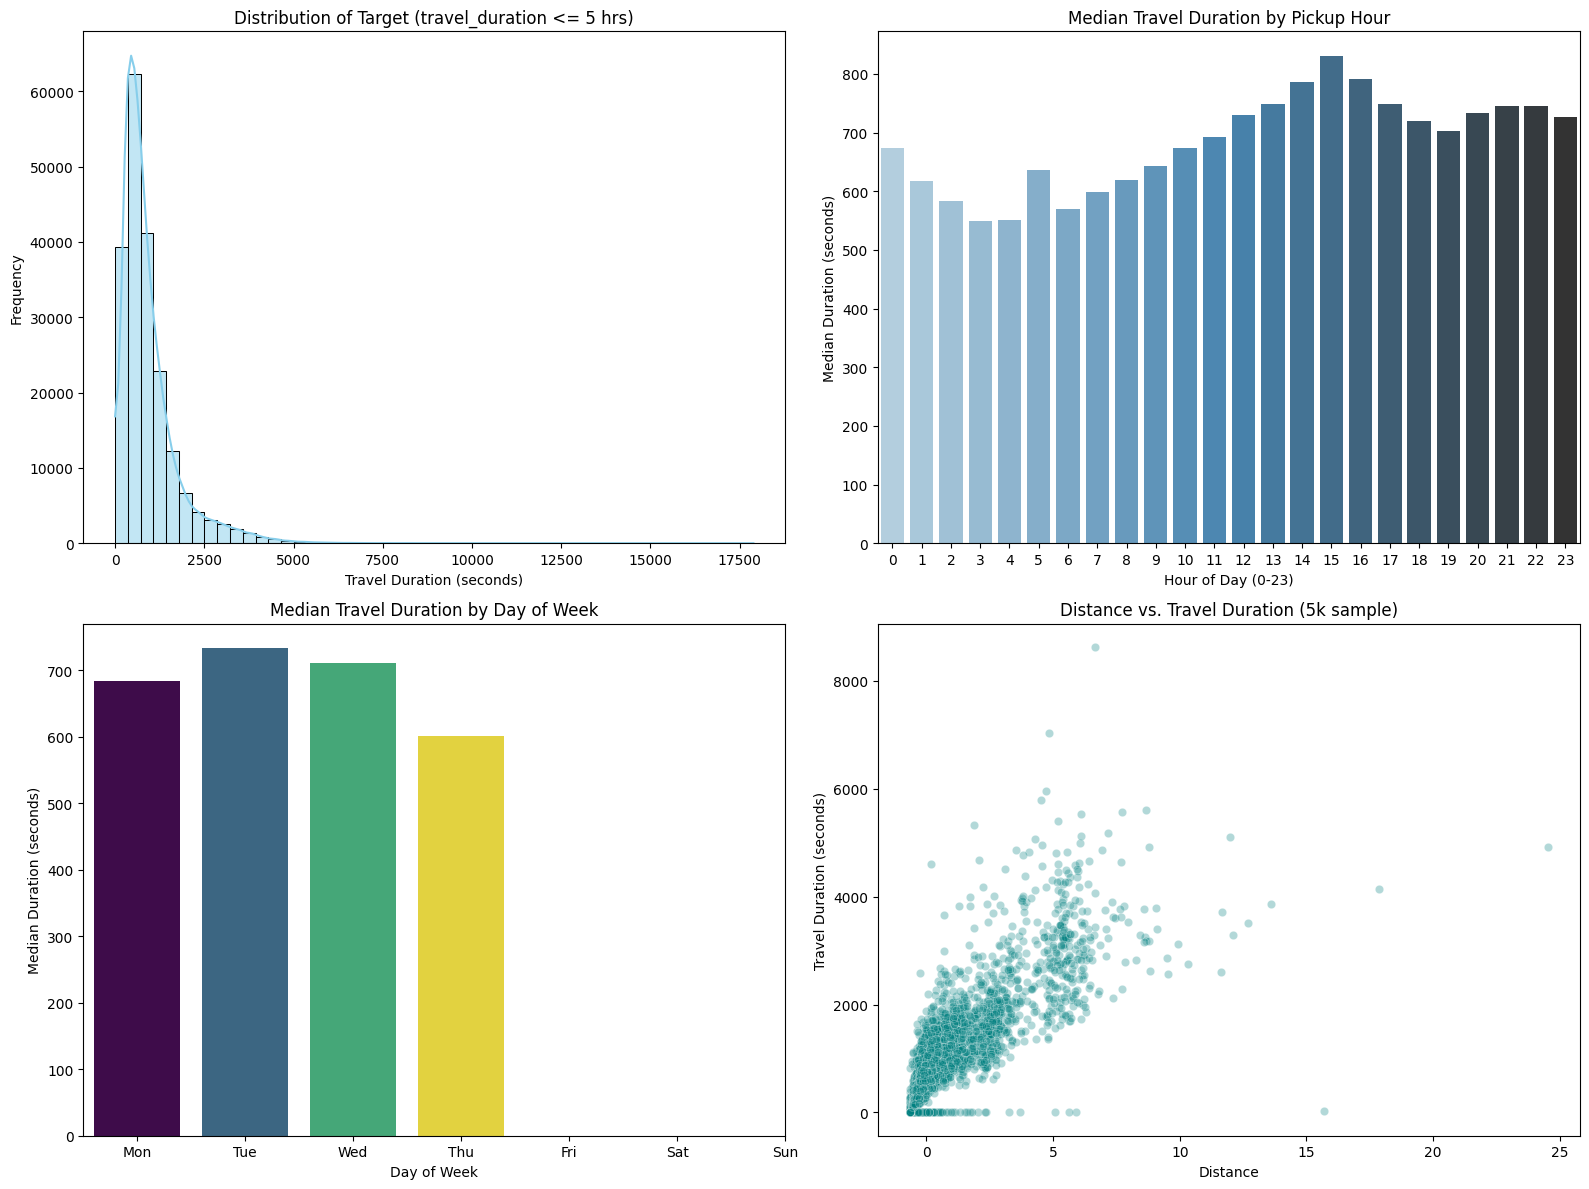

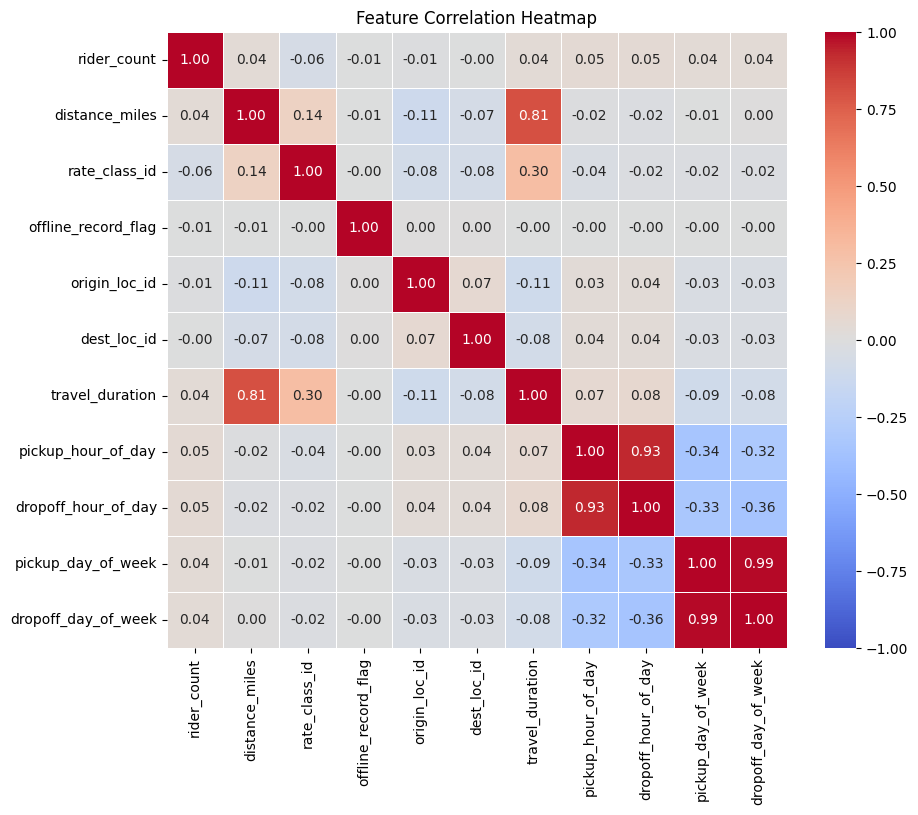

13052

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

file_path = '/content/drive/MyDrive/Telementors/Fare/Trav_estimator/Train_ready_travel.csv'
target_col = 'travel_duration'

print("--- 1. LOADING SAMPLE FOR VISUALIZATION ---")
# Load a safe subset of rows to avoid memory limits during plotting
eda_df = pd.read_csv(file_path, nrows=200000)

# Optional: Filter extreme target outliers for cleaner EDA (e.g., trips > 5 hours / 18,000s)
eda_df_clean = eda_df[eda_df[target_col] <= 18000].copy()

plt.figure(figsize=(16, 12))

# 3.1 Target Variable Distribution
plt.subplot(2, 2, 1)
sns.histplot(eda_df_clean[target_col], bins=50, kde=True, color='skyblue')
plt.title(f'Distribution of Target ({target_col} <= 5 hrs)')
plt.xlabel('Travel Duration (seconds)')
plt.ylabel('Frequency')

# 3.2 Pickup Hour vs Median Travel Duration
plt.subplot(2, 2, 2)
if 'pickup_hour_of_day' in eda_df_clean.columns:
    hourly_travel = eda_df_clean.groupby('pickup_hour_of_day')[target_col].median().reset_index()
    sns.barplot(
        data=hourly_travel,
        x='pickup_hour_of_day',
        y=target_col,
        hue='pickup_hour_of_day',
        palette='Blues_d',
        legend=False
    )
    plt.title('Median Travel Duration by Pickup Hour')
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Median Duration (seconds)')

# 3.3 Pickup Day of Week vs Median Travel Duration
plt.subplot(2, 2, 3)
if 'pickup_day_of_week' in eda_df_clean.columns:
    daily_travel = eda_df_clean.groupby('pickup_day_of_week')[target_col].median().reset_index()
    sns.barplot(
        data=daily_travel,
        x='pickup_day_of_week',
        y=target_col,
        hue='pickup_day_of_week',
        palette='viridis',  # Fixed: lowercase 'viridis'
        legend=False
    )
    plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    plt.title('Median Travel Duration by Day of Week')
    plt.xlabel('Day of Week')
    plt.ylabel('Median Duration (seconds)')

# 3.4 Distance vs Travel Duration Scatter
plt.subplot(2, 2, 4)
if 'distance_miles' in eda_df_clean.columns:
    sns.scatterplot(data=eda_df_clean.sample(5000), x='distance_miles', y=target_col, alpha=0.3, color='teal')
    plt.title('Distance vs. Travel Duration (5k sample)')
    plt.xlabel('Distance')
    plt.ylabel('Travel Duration (seconds)')

plt.tight_layout()
plt.show()

# --- 4. FEATURE CORRELATION HEATMAP ---
plt.figure(figsize=(10, 8))
corr_matrix = eda_df_clean.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Clean up memory
del eda_df, eda_df_clean
gc.collect()

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle
import os
import gc

file_path = '/content/drive/MyDrive/Telementors/Fare/Trav_estimator/Train_ready_travel.csv'
pkl_save_path = '/content/drive/MyDrive/Telementors/Fare/Trav_estimator/xgboost_travel_model.pkl'
target_col = 'travel_duration'

print("1. Loading dataset in chunks and removing target outliers...")

# Load and filter out extreme duration outliers (e.g., duration <= 0 or > 3 hours)
chunks = []
for chunk in pd.read_csv(file_path, chunksize=100000, low_memory=False):
    # Filter valid travel durations
    filtered_chunk = chunk[(chunk[target_col] > 0) & (chunk[target_col] <= 10800)]
    chunks.append(filtered_chunk)

df = pd.concat(chunks, axis=0, ignore_index=True)
del chunks
gc.collect()

# Separate features (X) and target (y)
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].astype('float32')
y = df[target_col].astype('float32')

del df
gc.collect()

print("2. Splitting dataset...")
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

del X, y
gc.collect()

print("3. Converting to DMatrix and Training XGBoost...")
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

del X_train, y_train, X_val
gc.collect()

# Model parameters
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'tree_method': 'hist',
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

evals = [(dtrain, 'train'), (dval, 'val')]
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=20,
    verbose_eval=100
)

# Evaluate performance
y_pred = model.predict(dval)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"Validation RMSE: {rmse:.4f} seconds")
print(f"Validation R²  : {r2:.4f}")

# 4. Save model as a .pkl file
print(f"\n4. Exporting model to .pkl...")
with open(pkl_save_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Successfully created and saved: {pkl_save_path}")

1. Loading dataset in chunks and removing target outliers...
2. Splitting dataset...
3. Converting to DMatrix and Training XGBoost...
[0]	train-rmse:780.52914	val-rmse:791.29773
[100]	train-rmse:304.14517	val-rmse:328.60851
[200]	train-rmse:283.04983	val-rmse:312.07546
[300]	train-rmse:270.59524	val-rmse:303.25135
[400]	train-rmse:261.61704	val-rmse:297.64020
[499]	train-rmse:254.66896	val-rmse:293.75441

--- Model Evaluation ---
Validation RMSE: 293.7544 seconds
Validation R²  : 0.8727

4. Exporting model to .pkl...
Successfully created and saved: /content/drive/MyDrive/Telementors/Fare/Trav_estimator/xgboost_travel_model.pkl
